In [2]:
import pandas as pd

train = pd.read_csv(r"C:\Users\OneDrive\Attachments\Desktop\MLchallange\ML Challenge Dataset\TRAIN.csv")
test = pd.read_csv(r"C:\Users\OneDrive\Attachments\Desktop\MLchallange\ML Challenge Dataset\TEST.csv")

In [3]:
print("Shape:", train.shape)
print("\nColumns:\n", train.columns)
print("\nInfo:\n")
print(train.info())

Shape: (43776, 48)

Columns:
 Index(['F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07', 'F08', 'F09', 'F10',
       'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20',
       'F21', 'F22', 'F23', 'F24', 'F25', 'F26', 'F27', 'F28', 'F29', 'F30',
       'F31', 'F32', 'F33', 'F34', 'F35', 'F36', 'F37', 'F38', 'F39', 'F40',
       'F41', 'F42', 'F43', 'F44', 'F45', 'F46', 'F47', 'Class'],
      dtype='object')

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43776 entries, 0 to 43775
Data columns (total 48 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   F01     43776 non-null  float64
 1   F02     43776 non-null  float64
 2   F03     43776 non-null  float64
 3   F04     43776 non-null  float64
 4   F05     43776 non-null  float64
 5   F06     43776 non-null  float64
 6   F07     43776 non-null  float64
 7   F08     43776 non-null  float64
 8   F09     43776 non-null  float64
 9   F10     43776 non-null  float64
 10  F11     

In [13]:
import os
print(os.getcwd())
train.describe().T.to_csv(
    r"C:\UsersOneDrive\Attachments\Desktop\MLchallange\ML Challenge Dataset\train_summary.csv"
)

C:\Users\ACER.DESKTOP-G5EVCFN\OneDrive\Attachments\Desktop\MLchallange


In [5]:
print(train["Class"].value_counts())
print(train["Class"].value_counts(normalize=True) * 100)

Class
0    26465
1    17311
Name: count, dtype: int64
Class
0    60.455501
1    39.544499
Name: proportion, dtype: float64


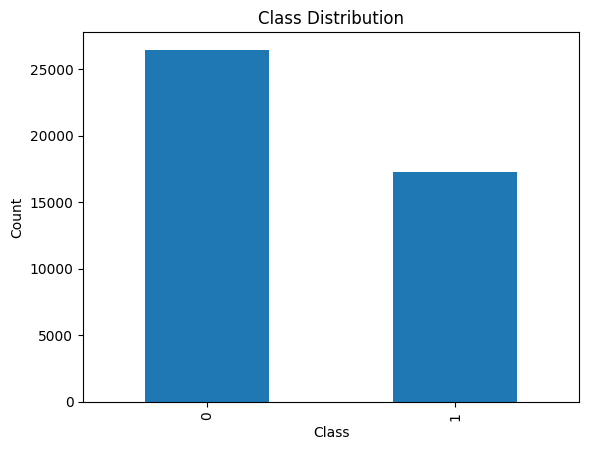

In [6]:
import matplotlib.pyplot as plt

train["Class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [7]:
train.isnull().sum().sum()

np.int64(0)

In [8]:
corr_with_target = train.corr()["Class"].sort_values(ascending=False)
print(corr_with_target)

Class    1.000000
F01      0.386981
F09      0.377363
F29      0.364944
F19      0.358187
F21      0.344699
F05      0.342236
F25      0.338634
F07      0.334932
F27      0.334544
F06      0.330080
F26      0.328719
F28      0.306282
F08      0.286445
F10      0.214676
F04      0.206409
F17      0.194926
F13      0.181472
F02      0.173721
F24      0.168340
F31      0.158734
F18      0.152234
F32      0.140558
F03      0.129184
F23      0.128011
F16      0.127797
F22      0.115186
F14      0.101185
F15      0.096387
F12      0.078615
F11      0.034260
F37      0.022306
F30      0.022144
F36      0.013119
F39      0.011001
F33      0.010982
F46      0.006908
F47      0.005219
F45      0.004567
F38      0.004186
F40      0.003154
F41     -0.000028
F20     -0.004982
F35     -0.005728
F42     -0.007027
F43     -0.008375
F44     -0.015088
F34     -0.024363
Name: Class, dtype: float64


In [14]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
F01,43776.0,5.675254e-01,0.738884,0.100025,0.198843,0.288778,0.528760,12.779628
F02,43776.0,1.428504e-02,0.019607,0.003001,0.004778,0.007988,0.014382,0.199925
F03,43776.0,1.555057e-02,0.022504,0.000752,0.005437,0.008905,0.016610,0.506419
F04,43776.0,2.677944e-02,0.050725,0.000682,0.006290,0.012619,0.027599,0.851009
F05,43776.0,8.763653e-02,0.188394,0.000835,0.012050,0.023681,0.063469,5.017180
F06,43776.0,1.551421e-01,0.377655,0.000854,0.014112,0.032396,0.115950,7.249545
F07,43776.0,1.506559e-01,0.339948,0.000702,0.015084,0.029157,0.116992,6.556998
F08,43776.0,2.556436e-01,0.354816,0.001399,0.072098,0.119095,0.265227,5.960009
F09,43776.0,3.611456e-01,0.440134,0.001164,0.128780,0.214665,0.381230,5.085546
F10,43776.0,3.762811e+00,1.271343,0.038349,3.192588,3.604579,4.035824,50.624777


In [18]:
X = train.drop(columns=["Class"])
y = train["Class"]

X_test = test.drop(columns=["ID"])

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_val, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_pred))

Accuracy: 0.9845820009136592

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      5293
           1       1.00      0.97      0.98      3463

    accuracy                           0.98      8756
   macro avg       0.99      0.98      0.98      8756
weighted avg       0.98      0.98      0.98      8756


Confusion Matrix:

[[5279   14]
 [ 121 3342]]


In [ ]:
Cross Validation Check!!

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(rf, X, y, cv=skf, scoring='accuracy')

print("Cross Validation Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

Cross Validation Scores: [0.9829831  0.98252427 0.98149629 0.98252427 0.98081097]
Mean CV Accuracy: 0.9820677787984625


Final Submission Random Classifier Model!

In [23]:
rf_final = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X, y)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
Accuracy check on the shuffled data! (Should be low!!!)

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import numpy as np

y_shuffled = np.random.permutation(y)

X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
    X, y_shuffled,
    test_size=0.2,
    random_state=42
)

rf_test = RandomForestClassifier(n_estimators=200, random_state=42)
rf_test.fit(X_train_s, y_train_s)

print("Validation accuracy on shuffled labels:",
      rf_test.score(X_val_s, y_val_s))

Validation accuracy on shuffled labels: 0.5849703060758337
